# Entraînement d’un classificateur pour sélectionner les articles pertinents du corpus TASS

Ce notebook documente la construction d’un classificateur supervisé destiné à isoler, dans le corpus TASS complet, les articles portant sur le déplacement forcé de personnes depuis l’Ukraine vers la Russie et sur les dispositifs d’accueil associés.

La démarche repose sur un sous-corpus annoté manuellement. À partir des titres d’articles, plusieurs modèles d’embeddings et plusieurs classificateurs sont comparés. La meilleure combinaison est ensuite sauvegardée, appliquée à l’ensemble du corpus, puis ajustée par un seuil de confiance afin de produire un sous-corpus plus fiable pour l’analyse qualitative.

Le notebook suit donc quatre étapes principales : préparation des données annotées (util d'annotation utilisé : LabelStudio), entraînement et comparaison des modèles, application du meilleur modèle au corpus complet, puis filtrage final des articles les plus pertinents.


## 1. Préparation de l’environnement


In [1]:
import json
import random
import pandas as pd
import numpy as np

## 2. Chargement du jeu de données annoté manuellement

Le fichier `annotated_data.csv` contient le sous-corpus utilisé pour l’entraînement. Chaque ligne correspond à un article déjà annoté, avec un label indiquant si l’article relève ou non de la thématique recherchée.

Dans ce notebook, la classification s’appuie principalement sur la colonne contenant le titre de l’article. Le label binaire sert de variable cible pour apprendre à distinguer les articles pertinents des articles hors sujet.


In [3]:
#import de données annotées pour l'entrainement 

df_all = pd.read_csv("annotated_data.csv")

df_all

,Titre de l'article,Date,Lien,label
0,Власти ДНР организовали массовый централизован...,2022-02-18 13:10:00,https://tass.ru/mezhdunarodnaya-panorama/13756493,1
1,"В Думе заявили, что Ростовская область справит...",2022-02-18 13:46:00,https://tass.ru/politika/13757209,1
2,Пескову неизвестно об эвакуации жителей Донбас...,2022-02-18 14:10:00,https://tass.ru/politika/13757849,1
3,Власти Крыма заявили о готовности принять жите...,2022-02-18 14:18:00,https://tass.ru/politika/13757407,1
4,ДНР и ЛНР объявили об эвакуации мирных жителей...,2022-02-18 15:19:00,https://tass.ru/mezhdunarodnaya-panorama/13758699,1
...,...,...,...,...
894,"Свыше 3,2 млн беженцев прибыли в РФ с территор...",2022-08-08T07:17:38,https://tass.ru/obschestvo/15418875,1
895,В Ленобласть на отдых в летнем лагере прибыли ...,2022-07-14T07:37:39,https://tass.ru/obschestvo/15211937,1
896,Более 11 тыс. эвакуированных из Донбасса отпра...,2022-02-23T05:53:22,https://tass.ru/obschestvo/13816305,1
897,Единовременную помощь получили почти 12 тыс. э...,2022-02-28T20:32:27,https://tass.ru/obschestvo/13907037,1


### 2.1. Vérification de la distribution des labels

Avant l’entraînement, on contrôle la répartition des classes. Cette étape permet d’identifier un éventuel déséquilibre entre articles pertinents et non pertinents, ce qui justifie ensuite l’usage de paramètres comme `class_weight="balanced"` pour certains classificateurs.


In [4]:
print("\nLabel counts:")
print(df_all["label"].value_counts())


Label counts:
label
0    455
1    444
Name: count, dtype: int64


## 3. Configuration de l’entraînement supervisé

Cette section importe les bibliothèques nécessaires à l’entraînement : modèles d’embeddings, séparation entraînement/test, classificateurs, métriques d’évaluation et outils de sauvegarde.

L’objectif est de comparer plusieurs combinaisons entre un modèle de représentation sémantique des titres et un algorithme de classification. Le choix final repose surtout sur les performances obtenues pour la classe 1, c’est-à-dire les articles considérés comme pertinents pour la recherche.


In [ ]:
# === Embeddings ===
from sentence_transformers import SentenceTransformer

# === Data & utils ===
import pandas as pd
import numpy as np
import random
import joblib

# === Splitting & validation ===
from sklearn.model_selection import train_test_split, StratifiedKFold

# === Classifiers ===
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# === Metrics ===
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score
)

# === Calibration / probabilities ===
from sklearn.calibration import CalibratedClassifierCV

# === Reproducibility ===
from sklearn.base import clone

from sklearn.metrics import accuracy_score


### 3.1. Préparation des textes et séparation entraînement/test

Les titres des articles sont convertis en chaînes de caractères, puis les labels sont transformés en valeurs numériques. Le jeu annoté est ensuite divisé en deux parties : une partie pour entraîner les modèles et une partie pour les évaluer.

La séparation est stratifiée afin de conserver une proportion similaire de labels 0 et 1 dans les ensembles d’entraînement et de test.


In [ ]:
print("Préparation du jeu de données...")

texts = df_all["Titre de l'article"].astype(str).fillna("")
y = df_all["label"].astype(int).values

X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    texts,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Séparation entraînement/test terminée.\n")

Préparation du jeu de données...
Séparation entraînement/test terminée.



### 3.2. Inspection rapide de l’ensemble de test

In [9]:
X_test_texts

751    На Чукотке направили около 500 млн рублей на д...
778    Русский дом в Пномпене передал гуманитарную по...
733    В Донецке более 80 горняков находятся в обесто...
237    У 30 жителей Донбасса, эвакуированных в Ростов...
640    Тульским школьникам из семей участников СВО пр...
                             ...                        
765    Тверская область направила жителям Донбасса ок...
604    Молодежь из ЛНР приняла участие в мероприятиях...
371              Соглашения с ДНР и ЛНР внесли в Госдуму
519    Украина отсрочила возвращение в энергетическую...
245    В санаториях и гостиницах Карелии готовы приня...
Name: Titre de l'article, Length: 180, dtype: object

### 3.3. Contrôle de l’équilibre des classes après la séparation

Cette vérification permet de comparer la proportion des classes dans les ensembles d’entraînement et de test. Elle confirme que la stratification a bien conservé une structure comparable entre les deux sous-ensembles.


In [10]:
print("Train distribution:", np.bincount(y_train) / len(y_train))
print("Test distribution:", np.bincount(y_test) / len(y_test))


Train distribution: [0.50625869 0.49374131]
Test distribution: [0.50555556 0.49444444]


## 4. Définition des modèles d’embeddings testés

Les titres sont transformés en vecteurs numériques à l’aide de modèles Sentence-BERT ou proches de SBERT. Ces embeddings représentent le contenu sémantique des titres et servent ensuite d’entrée aux classificateurs.

Plusieurs modèles sont testés afin de comparer la performance de représentations russophones et multilingues sur cette tâche spécifique.


In [26]:
print("Chargement des modèles d'embeddings...")

embedding_models = {
    # =========================
    # CORE — modèles principaux
    # =========================

    # (1) Meilleur candidat RU (multi-task SBERT, Sber AI)
    # Excellent pour titres courts, discours institutionnel.
    "sbert_ru_large_mt": "ai-forever/sbert_large_mt_nlu_ru",

    # (2) SBERT russe (single-task) — bon point de comparaison intra-RU
    "sbert_ru_large": "ai-forever/sbert_large_nlu_ru",

    # (3) Modèle SOTA multilingue pour similarité sémantique
    # Recommandé pour tâches de classification sémantique
    "e5_large_multilingual": "intfloat/multilingual-e5-large"}

print("Modèles d'embeddings prêts.\n")


Chargement des modèles d'embeddings...
Modèles d'embeddings prêts.



## 5. Définition des classificateurs testés

Trois familles de modèles sont comparées : régression logistique, SVM linéaire et forêt aléatoire. Ces modèles reçoivent en entrée les embeddings des titres et apprennent à prédire si un article appartient ou non à la thématique étudiée.

Les options de pondération des classes sont utilisées pour limiter l’effet d’un éventuel déséquilibre dans le jeu annoté.


In [13]:
classifiers = {
    # Baseline solide + probabilités -> utile pour ajuster un seuil (0.9)
    "LogReg": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        n_jobs=-1
    ),

    # Gold standard pour la classification de textes (robuste, rapide)
    # NB: pas de predict_proba -> можно калибровать отдельно si besoin
    "LinearSVC": LinearSVC(
        class_weight="balanced",
        random_state=42
    ),

    # Très robuste sur des embeddings, capte des motifs non-linéaires
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )
}

results = []

### 5.1. Dossier de sortie des résultats

Les résultats du benchmark, le meilleur classificateur et les informations sur le modèle d’embeddings retenu sont sauvegardés dans le dossier `benchmark_results`. Cette sauvegarde permet de réutiliser le modèle sans relancer toute la phase d’entraînement.


In [14]:
import os

# =====================================================================
# Dossier de sortie pour les résultats
# =====================================================================
OUTPUT_DIR = "benchmark_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)


### 5.2. Barre de progression

`tqdm` est utilisé pour suivre l’avancement du benchmark, qui peut être relativement long puisque plusieurs modèles d’embeddings et plusieurs classificateurs sont testés successivement.


In [18]:
from tqdm.notebook import tqdm  

### 5.3. Gestion de la mémoire

Cette cellule importe les outils utilisés pour libérer la mémoire entre deux modèles d’embeddings. Cette précaution est importante lorsque les modèles sont volumineux ou lorsque l’entraînement est exécuté sur une machine avec des ressources limitées.


In [23]:
import gc
import torch

## 6. Benchmark des combinaisons embeddings + classificateur

Cette cellule constitue le cœur de l’entraînement. Pour chaque modèle d’embeddings, les titres du jeu d’entraînement et du jeu de test sont encodés, puis chaque classificateur est entraîné et évalué.

Les performances sont calculées avec plusieurs métriques : accuracy, précision, rappel et F1-score pour la classe 1. Le meilleur modèle est sélectionné à partir du F1-score de la classe pertinente, puis sauvegardé sur disque avec les informations nécessaires pour le recharger ensuite.


In [27]:
print("Début de l'évaluation des modèles...\n")

results = []

best = {
    "f1": -1.0,
    "acc": None,
    "prec": None,
    "rec": None,
    "emb_name": None,
    "emb_path": None,
    "clf_name": None,
    "clf_fitted": None,
}

# --- настройки для предотвращения OOM на Mac ---
DEVICE = "cpu"         # ключевое: избегаем MPS OOM
BATCH_SIZE = 16        # было 64 -> слишком много для крупных моделей
EMB_NORM = True        # нормализация часто стабилизирует классификацию

for emb_name, emb_path in tqdm(embedding_models.items(), desc="Modèles d'embeddings", ncols=100):

    print(f"\n==============================")
    print(f"Modèle d'embeddings utilisé : {emb_name}")
    print("➡ Chargement du modèle...")

    # force CPU to avoid MPS out of memory
    model = SentenceTransformer(emb_path, device=DEVICE)

    # Опционально: для E5 можно добавить префикс
    if "e5" in emb_name.lower() or "e5" in emb_path.lower():
        train_texts = ["passage: " + t for t in list(X_train_texts)]
        test_texts  = ["passage: " + t for t in list(X_test_texts)]
    else:
        train_texts = list(X_train_texts)
        test_texts  = list(X_test_texts)

    print("➡ Génération des embeddings pour les textes d'entraînement...")
    X_train_emb = model.encode(
        train_texts,
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=EMB_NORM
    )

    print("➡ Génération des embeddings pour les textes de test...")
    X_test_emb = model.encode(
        test_texts,
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=EMB_NORM
    )

    print(f"Embeddings générés pour le modèle {emb_name}.\n")

    # =================================================================
    # Test des classificateurs
    # =================================================================
    for clf_name, clf in tqdm(classifiers.items(), desc=f"Classificateurs ({emb_name})", ncols=100):

        print(f"\n  Test du classificateur : {clf_name}")

        clf_local = clone(clf)
        clf_local.fit(X_train_emb, y_train)
        y_pred = clf_local.predict(X_test_emb)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, pos_label=1)
        prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
        rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0)

        print(f"     → Accuracy  : {acc:.3f}")
        print(f"     → Précision : {prec:.3f}")
        print(f"     → Rappel    : {rec:.3f}")
        print(f"     → F1-score  : {f1:.3f}")

        results.append({
            "Modèle d'embeddings": emb_name,
            "Classificateur": clf_name,
            "Accuracy": acc,
            "F1 (classe=1)": f1,
            "Précision (classe=1)": prec,
            "Rappel (classe=1)": rec
        })

        if f1 > best["f1"]:
            best.update({
                "f1": f1,
                "acc": acc,
                "prec": prec,
                "rec": rec,
                "emb_name": emb_name,
                "emb_path": emb_path,
                "clf_name": clf_name,
                "clf_fitted": clf_local,
            })

            print("Nouveau meilleur modèle sauvegardé !")
            print(f"   -> Embeddings      : {emb_name}")
            print(f"   -> Classifieur     : {clf_name}")
            print(f"   -> F1 (classe=1)   : {f1:.6f}")

    # =================================================================
    # Nettoyage mémoire entre modèles (important)
    # =================================================================
    del model, X_train_emb, X_test_emb
    gc.collect()
    # si torch est chargé, on peut aussi libérer le cache (même en CPU c'est OK)
    if torch.backends.mps.is_available():
        try:
            torch.mps.empty_cache()
        except Exception:
            pass

# =====================================================================
# Tableau final trié par F1
# =====================================================================
import pandas as pd
import joblib

results_df = (
    pd.DataFrame(results)
    .sort_values("F1 (classe=1)", ascending=False)
    .reset_index(drop=True)
)

results_path = os.path.join(OUTPUT_DIR, "benchmark_results.csv")
results_df.to_csv(results_path, index=False, encoding="utf-8-sig")

print("\n=====================================================")
print("Meilleure combinaison finale :")
print(f"Embeddings     : {best['emb_name']}")
print(f"Classificateur : {best['clf_name']}")
print(f"Accuracy       : {best['acc']:.6f}")
print(f"F1 (classe=1)  : {best['f1']:.6f}")
print(f"Précision (1)  : {best['prec']:.6f}")
print(f"Rappel (1)     : {best['rec']:.6f}")
print("=====================================================\n")

clf_path = os.path.join(OUTPUT_DIR, "best_classifier.joblib")
emb_info_path = os.path.join(OUTPUT_DIR, "best_embedding_info.joblib")

joblib.dump(best["clf_fitted"], clf_path)
joblib.dump(
    {"emb_name": best["emb_name"], "emb_path": best["emb_path"]},
    emb_info_path
)

print("Sauvegarde disque terminée :")
print(f" - {clf_path}")
print(f" - {emb_info_path}")
print(f" - {results_path}")


Début de l'évaluation des modèles...



Modèles d'embeddings:   0%|                                                   | 0/3 [00:00<?, ?it/s]


Modèle d'embeddings utilisé : sbert_ru_large_mt
➡ Chargement du modèle...
➡ Génération des embeddings pour les textes d'entraînement...


Batches:   0%|          | 0/45 [00:00<?, ?it/s]

➡ Génération des embeddings pour les textes de test...


...

Embeddings générés pour le modèle e5_large_multilingual.



Classificateurs (e5_large_multilingual):   0%|                                | 0/3 [00:00<?, ?it/s]


  Test du classificateur : LogReg
     → Accuracy  : 0.906
     → Précision : 0.875
     → Rappel    : 0.944
     → F1-score  : 0.908

  Test du classificateur : LinearSVC
     → Accuracy  : 0.933
     → Précision : 0.897
     → Rappel    : 0.978
     → F1-score  : 0.935

  Test du classificateur : RandomForest


/opt/miniconda3/envs/env_memoire_nlp/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


     → Accuracy  : 0.922
     → Précision : 0.912
     → Rappel    : 0.933
     → F1-score  : 0.922

Meilleure combinaison finale :
Embeddings     : sbert_ru_large
Classificateur : LinearSVC
Accuracy       : 0.938889
F1 (classe=1)  : 0.940541
Précision (1)  : 0.906250
Rappel (1)     : 0.977528

Sauvegarde disque terminée :
 - benchmark_results/best_classifier.joblib
 - benchmark_results/best_embedding_info.joblib
 - benchmark_results/benchmark_results.csv


### 6.1. Tableau des résultats du benchmark

Le tableau `results_df` rassemble les scores obtenus pour chaque combinaison de modèle d’embeddings et de classificateur. Il permet de comparer les performances et d’identifier la solution la plus adaptée à la tâche de filtrage du corpus.


In [28]:
results_df

,Modèle d'embeddings,Classificateur,Accuracy,F1 (classe=1),Précision (classe=1),Rappel (classe=1)
0,sbert_ru_large,LinearSVC,0.938889,0.940541,0.906250,0.977528
1,e5_large_multilingual,LinearSVC,0.933333,0.935484,0.896907,0.977528
2,sbert_ru_large,RandomForest,0.933333,0.933333,0.923077,0.943820
3,sbert_ru_large_mt,LogReg,0.922222,0.923913,0.894737,0.955056
4,e5_large_multilingual,RandomForest,0.922222,0.922222,0.912088,0.932584
5,sbert_ru_large_mt,LinearSVC,0.922222,0.921348,0.921348,0.921348
6,sbert_ru_large_mt,RandomForest,0.911111,0.910112,0.910112,0.910112
7,sbert_ru_large,LogReg,0.905556,0.909091,0.867347,0.955056
8,e5_large_multilingual,LogReg,0.905556,0.908108,0.875000,0.943820


## 7. Visualisation du choix du meilleur modèle

Cette section permet de représenter les performances sous forme de tableau croisé et de carte de chaleur. L’objectif est de rendre plus lisible la comparaison entre les modèles d’embeddings et les classificateurs testés.


In [31]:
import matplotlib.pyplot as plt

### 7.1. Construction du tableau croisé des F1-scores

Le tableau croisé place les modèles d’embeddings en lignes et les classificateurs en colonnes. Chaque cellule correspond au F1-score obtenu pour la classe 1.


In [32]:
pivot_f1 = results_df.pivot(
    index="Modèle d'embeddings",
    columns="Classificateur",
    values="F1 (classe=1)"
)

print("Pivot table créée.")
pivot_f1

Pivot table créée.


Classificateur,LinearSVC,LogReg,RandomForest
Modèle d'embeddings,,,
e5_large_multilingual,0.935484,0.908108,0.922222
sbert_ru_large,0.940541,0.909091,0.933333
sbert_ru_large_mt,0.921348,0.923913,0.910112


### 7.2. Carte de chaleur des performances

Le graphique permet de repérer visuellement les combinaisons les plus performantes. Les valeurs les plus élevées indiquent les modèles les plus efficaces pour identifier les articles pertinents.


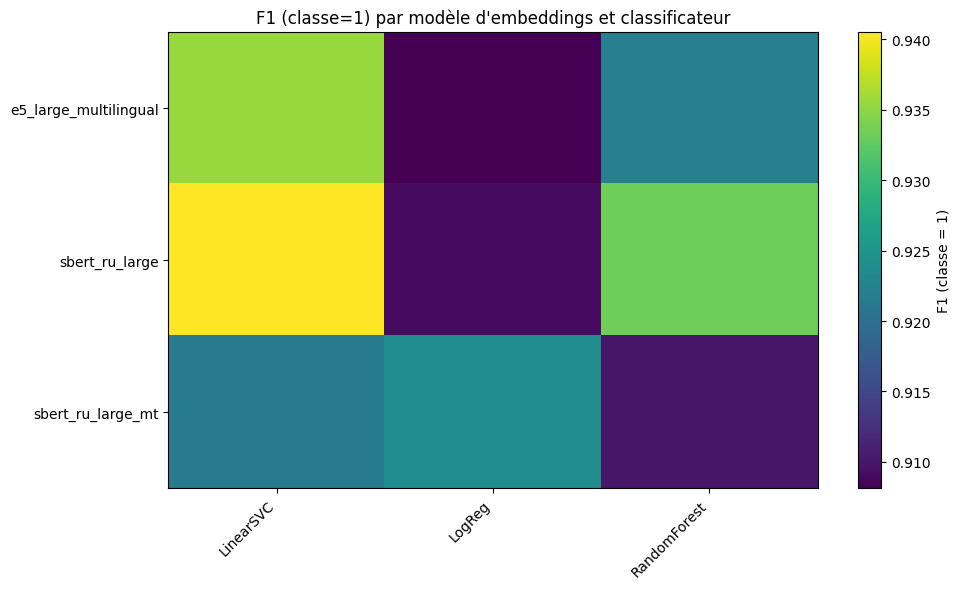

In [33]:
plt.figure(figsize=(10, 6))
im = plt.imshow(pivot_f1.values, aspect="auto")

plt.xticks(
    ticks=np.arange(len(pivot_f1.columns)),
    labels=pivot_f1.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    ticks=np.arange(len(pivot_f1.index)),
    labels=pivot_f1.index
)

plt.colorbar(im, label="F1 (classe = 1)")
plt.title("F1 (classe=1) par modèle d'embeddings et classificateur")
plt.tight_layout()
plt.show()


# Application du modèle au corpus TASS complet

Une fois la meilleure combinaison sélectionnée, le modèle est appliqué à l’ensemble du corpus TASS collecté précédemment. L’objectif est d’annoter automatiquement chaque article du corpus avec une prédiction binaire et, lorsque le classificateur le permet, un score de décision.


In [43]:
import json
from datetime import datetime

## 8. Chargement et vérification du corpus complet

Cette cellule charge le fichier `tass_minimal_progress.json`, qui contient l’ensemble des articles collectés. Elle extrait les dates de publication afin de vérifier la période couverte par le corpus et le nombre total d’articles disponibles avant classification.


In [44]:
json_path = "tass_minimal_progress.json"

# ============================================================
# 1. Chargement du fichier
# ============================================================

with open(json_path, "r", encoding="utf-8") as f:
    items = json.load(f)

print(f"Fichier chargé : {json_path}")
print(f"Nombre total d'articles : {len(items)}")

# ============================================================
# 2. Extraction des dates de publication
# ============================================================

dates = []

for it in items:
    # защита на случай, если элемент не словарь
    if not isinstance(it, dict):
        continue

    dt_str = it.get("published_dt")
    if not dt_str:
        continue

    try:
        # формат: 2022-02-18T22:58:34
        dt = datetime.fromisoformat(dt_str)
        dates.append(dt)
    except ValueError:
        pass

if not dates:
    raise ValueError("Aucune date valide n'a pu être extraite du fichier.")

# ============================================================
# 3. Période couverte par le corpus
# ============================================================

date_min = min(dates)
date_max = max(dates)

print("\nPériode couverte par le corpus :")
print(f"Date la plus ancienne : {date_min}")
print(f"Date la plus récente  : {date_max}")
print(f"Nombre total d'articles : {len(items)}")

# ============================================================
# 4. Affichage sans l'heure (optionnel)
# ============================================================

print("\nPériode (dates uniquement) :")
print(f"Du {date_min.date()} au {date_max.date()}")


Fichier chargé : tass_minimal_progress.json
Nombre total d'articles : 1176210

Période couverte par le corpus :
Date la plus ancienne : 2022-02-17 23:05:47
Date la plus récente  : 2025-12-11 16:23:29
Nombre total d'articles : 1176210

Période (dates uniquement) :
Du 2022-02-17 au 2025-12-11


## 9. Chargement du modèle entraîné

Cette section recharge le meilleur classificateur sauvegardé pendant le benchmark ainsi que le modèle d’embeddings correspondant. Elle prépare aussi les chemins d’entrée et de sortie pour l’annotation automatique du corpus complet.


In [55]:
import os
import json
import ijson
from tqdm import tqdm

In [56]:
import ijson

### 9.1. Préparation de la classification du corpus complet

Le notebook charge le classificateur, récupère le chemin du modèle d’embeddings retenu et compte le nombre d’objets dans le fichier JSON d’entrée. Ce comptage sert à afficher une barre de progression pendant la classification.


In [57]:
json_path = "tass_minimal_progress.json"
out_path = "benchmark_results/tass_minimal_progress_labeled.json"  # новый файл с лейблами

print("➡ Chargement du classificateur et du modèle d'embeddings...")

best_clf = joblib.load("benchmark_results/best_classifier.joblib")
best_emb_info = joblib.load("benchmark_results/best_embedding_info.joblib")
emb_model = SentenceTransformer(best_emb_info["emb_path"])

print(f"Embeddings : {best_emb_info['emb_name']}")
print("Classificateur chargé.")

# (Опционально) оценка количества элементов для tqdm (быстро, но всё равно проход по файлу)
print("Comptage des éléments du JSON (pour la barre de progression)...")
with open(json_path, "rb") as f:
    n_items = sum(1 for _ in ijson.items(f, "item"))
print(f"Nombre d'objets : {n_items}")


➡ Chargement du classificateur et du modèle d'embeddings...
Embeddings : sbert_ru_large
Classificateur chargé.
Comptage des éléments du JSON (pour la barre de progression)...
Nombre d'objets : 1176210


## 10. Classification automatique du corpus complet

Cette cellule annote le corpus article par article. Pour limiter les risques d’interruption et permettre une reprise, le traitement est effectué en streaming et les résultats sont écrits progressivement dans un nouveau fichier JSON.

Chaque article reçoit un champ `pred_label`, qui indique la classe prédite. Lorsque le classificateur le permet, un champ `pred_score` est également ajouté : il mesure la distance de l’article à la frontière de décision du SVM et sera utilisé ensuite pour un filtrage plus strict.


In [58]:
# ----------------- Paramètres -----------------
BATCH_SIZE = 64
TEXT_KEY = "title"
AUTOSAVE_EVERY = 1000

# Doivent être définis avant:
# json_path (input), out_path (output), n_items (nombre d'items dans input)
# best_clf, emb_model

# ----------------- Helpers -----------------
def count_labeled_by_pred_label(path: str) -> int:
    """
    Compte le nombre d'objets déjà écrits dans le fichier de sortie
    en comptant les occurrences du champ "pred_label".
    Ne dépend pas du formatage (sauts de ligne / virgules).
    """
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        return 0

    count = 0
    with open(path, "rb") as f:
        while True:
            chunk = f.read(1024 * 1024)
            if not chunk:
                break
            count += chunk.count(b'"pred_label"')
    return count


def truncate_closing_bracket_if_present(path: str):
    """
    Si le fichier se termine par ']' (avec espaces/retours), on retire
    cette bracket afin de pouvoir continuer à écrire dans le tableau JSON.
    """
    with open(path, "rb+") as f:
        f.seek(0, os.SEEK_END)
        end = f.tell()
        if end == 0:
            return

        read_len = min(4096, end)
        f.seek(end - read_len)
        tail = f.read(read_len)

        stripped = tail.rstrip()
        if not stripped:
            return

        if stripped.endswith(b"]"):
            idx = stripped.rfind(b"]")
            new_size = (end - read_len) + idx
            f.truncate(new_size)


def ensure_json_array_started(path: str):
    """
    S'assure que le fichier de sortie existe et commence par "[\\n".
    Retourne un bool 'first' indiquant si on doit écrire le premier objet
    sans virgule.
    """
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        with open(path, "w", encoding="utf-8") as fout:
            fout.write("[\n")
        return True

    # Fichier existe: on enlève ']' s'il est présent
    truncate_closing_bracket_if_present(path)

    # Si le fichier ne contient que "[\n" (ou proche), on est sur le premier objet
    with open(path, "rb") as f:
        head = f.read(16).lstrip()

    return (head.startswith(b"[") and b"{" not in head)


# ----------------- RESUME -----------------
already = count_labeled_by_pred_label(out_path)
print(f"Reprise : objets déjà enregistrés dans out_path = {already}")

first = ensure_json_array_started(out_path)

# Si le fichier contient déjà des objets, alors 'first' doit être False
# même si ensure_json_array_started a un doute: on force avec already
if already > 0:
    first = False

processed = already

# ----------------- Traitement principal -----------------
with open(json_path, "rb") as fin, open(out_path, "a", encoding="utf-8") as fout:
    parser = ijson.items(fin, "item")

    # On saute les objets déjà traités dans l'input (resume par position)
    for _ in range(already):
        try:
            next(parser)
        except StopIteration:
            break

    batch_objs, batch_texts = [], []

    for obj in tqdm(parser, total=max(n_items - already, 0), desc="Annotation (reprise)", ncols=100):
        text = str(obj.get(TEXT_KEY, "") or "")
        batch_objs.append(obj)
        batch_texts.append(text)

        if len(batch_texts) >= BATCH_SIZE:
            X = emb_model.encode(
                batch_texts,
                batch_size=BATCH_SIZE,
                show_progress_bar=False,
                convert_to_numpy=True
            )

            # --- prédictions + score (margin SVM) ---
            preds = best_clf.predict(X)

            # decision_function renvoie la "distance à l'hyperplan" (margin)
            # (si classif binaire: shape (n_samples,))
            scores = best_clf.decision_function(X) if hasattr(best_clf, "decision_function") else None

            # proba optionnelle si modèle calibré
            proba1 = best_clf.predict_proba(X)[:, 1] if hasattr(best_clf, "predict_proba") else None

            for i, o in enumerate(batch_objs):
                o["pred_label"] = int(preds[i])

                if scores is not None:
                    o["pred_score"] = float(scores[i])

                if proba1 is not None:
                    o["pred_proba_1"] = float(proba1[i])

                if not first:
                    fout.write(",\n")
                fout.write(json.dumps(o, ensure_ascii=False))
                first = False
                processed += 1

                if processed % AUTOSAVE_EVERY == 0:
                    fout.flush()
                    print(f"Autosave : {processed} objets sauvegardés")

            batch_objs, batch_texts = [], []

    # Dernier batch
    if batch_texts:
        X = emb_model.encode(
            batch_texts,
            batch_size=BATCH_SIZE,
            show_progress_bar=False,
            convert_to_numpy=True
        )

        preds = best_clf.predict(X)
        scores = best_clf.decision_function(X) if hasattr(best_clf, "decision_function") else None
        proba1 = best_clf.predict_proba(X)[:, 1] if hasattr(best_clf, "predict_proba") else None

        for i, o in enumerate(batch_objs):
            o["pred_label"] = int(preds[i])

            if scores is not None:
                o["pred_score"] = float(scores[i])

            if proba1 is not None:
                o["pred_proba_1"] = float(proba1[i])

            if not first:
                fout.write(",\n")
            fout.write(json.dumps(o, ensure_ascii=False))
            first = False
            processed += 1

    # Fermer le tableau JSON
    fout.write("\n]\n")
    fout.flush()

print(f"Terminé. Fichier annoté (reprise) : {out_path}")
print(f"Total objets traités : {processed}")


Reprise : objets déjà enregistrés dans out_path = 0


Annotation (reprise):   0%|                                | 1024/1176210 [00:11<3:43:43, 87.55it/s]

Autosave : 1000 objets sauvegardés


Annotation (reprise):   0%|                                | 2048/1176210 [00:22<3:23:12, 96.30it/s]

Autosave : 2000 objets sauvegardés


...

Autosave : 1175000 objets sauvegardés


Annotation (reprise): 100%|████████████████████████████▉| 1176000/1176210 [9:10:27<00:07, 26.62it/s]

Autosave : 1176000 objets sauvegardés


Annotation (reprise): 100%|█████████████████████████████| 1176210/1176210 [9:10:34<00:00, 35.61it/s]


Terminé. Fichier annoté (reprise) : benchmark_results/tass_minimal_progress_labeled.json
Total objets traités : 1176210


## 12. Ajustement du seuil de décision

Le classificateur retenu est un **LinearSVC** entraîné sur des embeddings de titres d’articles. Pour chaque article, il produit un score de décision (`pred_score`) correspondant à la distance signée entre l’observation et l’hyperplan de séparation :

- `score > 0` : l’article est classé comme pertinent ;
- `score < 0` : l’article est classé comme non pertinent ;
- plus le score est élevé, plus la prédiction en faveur de la classe 1 est assurée.

Le seuil standard `score > 0` maximise souvent le rappel, mais il peut intégrer des articles ambigus situés près de la frontière de décision. Dans ce travail, l’objectif est de constituer un sous-corpus à haute précision pour l’analyse qualitative. Le seuil est donc rendu plus strict afin de réduire les faux positifs.

La méthode consiste à tester plusieurs seuils sur l’ensemble de test, puis à retenir le seuil le plus faible respectant une contrainte de précision minimale. Le seuil retenu est ensuite appliqué à l’ensemble du corpus TASS annoté automatiquement.


## 11. Premier filtrage : conservation des articles prédits pertinents

Cette cellule produit un premier sous-corpus en conservant uniquement les articles dont `pred_label = 1`. Ce filtrage correspond à la règle de décision standard du classificateur.

Le fichier obtenu peut servir de version large du corpus thématique, mais il peut encore contenir des faux positifs, notamment parmi les articles proches de la frontière de décision.


In [59]:
input_path = "benchmark_results/tass_minimal_progress_labeled.json"
output_path = "benchmark_results/tass_only_pred_label_1.json"

# ============================================================
# 1. Chargement du fichier
# ============================================================

with open(input_path, "r", encoding="utf-8") as f:
    items = json.load(f)

print(f"Nombre total d'éléments chargés : {len(items)}")

# ============================================================
# 2. Filtrage des éléments avec pred_label = 1
# ============================================================

filtered_items = []
missing = 0

for it in items:
    if not isinstance(it, dict):
        continue

    if "pred_label" not in it:
        missing += 1
        continue

    val = it.get("pred_label")

    # accepte 1 (int) ou "1" (str)
    if val == 1 or val == "1":
        filtered_items.append(it)

print(f"Nombre d'éléments avec pred_label = 1 : {len(filtered_items)}")
print(f"Éléments sans champ 'pred_label' : {missing}")

# ============================================================
# 3. Sauvegarde du nouveau fichier
# ============================================================

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(filtered_items, f, ensure_ascii=False, indent=2)

print(f"Fichier sauvegardé avec succès : {output_path}")


Nombre total d'éléments chargés : 1176210
Nombre d'éléments avec pred_label = 1 : 8795
Éléments sans champ 'pred_label' : 0
Fichier sauvegardé avec succès : benchmark_results/tass_only_pred_label_1.json


### 11.1. Vérification des champs disponibles

Cette cellule inspecte les clés présentes dans les premiers objets du fichier annoté. Elle permet de vérifier que les champs ajoutés par la classification, notamment `pred_label` et `pred_score`, ont bien été enregistrés.


In [60]:
all_keys = set()

for it in items[:1000]:  # берём первые 1000 для скорости
    if isinstance(it, dict):
        all_keys.update(it.keys())

all_keys


{'pred_label', 'pred_score', 'published_dt', 'title', 'url'}

## 12. Évaluation de plusieurs seuils de décision

Pour réduire les faux positifs, cette cellule calcule les scores de décision sur l’ensemble de test, puis évalue plusieurs seuils possibles. Pour chaque seuil, elle mesure le nombre d’articles prédits positifs, la précision, le rappel, le F1-score, ainsi que les vrais positifs, faux positifs et faux négatifs.

Le seuil final est choisi selon une contrainte de précision minimale. Cette logique est adaptée à un corpus destiné à l’analyse qualitative : il est préférable de retenir moins d’articles, mais d’avoir une plus grande confiance dans leur pertinence.


In [66]:
# =====================================================================
# 2) Embeddings (test) + scores SVM
# =====================================================================
print("Encodage SBERT du test set...")
X_test = emb_model.encode(
    X_test_texts.tolist(),
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True
)

if not hasattr(best_clf, "decision_function"):
    raise AttributeError("Le classificateur ne possède pas de méthode decision_function().")

print("Calcul des scores (margin) sur le test set...")
scores_test = best_clf.decision_function(X_test)

# =====================================================================
# 3) Évaluation pour différents seuils
# =====================================================================
print("Évaluation de plusieurs seuils (seuil = T) ...")

# Seuils candidats: quantiles => plus robuste que linspace
quantiles = [0.00, 0.25, 0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.97, 0.99]
thresholds = np.unique(np.quantile(scores_test, quantiles))

rows = []
n_test = len(y_test)
n_pos_test = int((y_test == 1).sum())

for T in thresholds:
    pred1 = scores_test > T
    n_pred1 = int(pred1.sum())

    if n_pred1 == 0:
        rows.append({
            "seuil_T": float(T),
            "nb_pred_1": 0,
            "precision_1": np.nan,
            "rappel_1": 0.0,
            "f1_1": np.nan,
            "fp": 0,
            "tp": 0,
            "fn": n_pos_test
        })
        continue

    tp = int(((y_test == 1) & pred1).sum())
    fp = int(((y_test == 0) & pred1).sum())
    fn = int(((y_test == 1) & (~pred1)).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision and recall and (precision + recall) > 0) else np.nan

    rows.append({
        "seuil_T": float(T),
        "nb_pred_1": n_pred1,
        "precision_1": precision,
        "rappel_1": recall,
        "f1_1": f1,
        "fp": fp,
        "tp": tp,
        "fn": fn
    })

df_seuils = pd.DataFrame(rows).sort_values("seuil_T", ascending=True)

print("\nRésumé (test set) :")
print(f"Nombre d'items test : {n_test}")
print(f"Nombre de vrais 1 dans le test : {n_pos_test}")

# Affichage lisible (tu peux ajuster les colonnes)
display(df_seuils[["seuil_T", "nb_pred_1", "precision_1", "rappel_1", "f1_1", "fp", "tp", "fn"]])

# =====================================================================
# 4) (Option) Trouver automatiquement un seuil avec contrainte de précision
# =====================================================================
TARGET_PRECISION = 0.95
MIN_PRED_1 = 20

candidates = df_seuils[
    (df_seuils["precision_1"] >= TARGET_PRECISION) &
    (df_seuils["nb_pred_1"] >= MIN_PRED_1)
].sort_values(["seuil_T"], ascending=True)

print(f"\nSeuils candidats avec précision ≥ {TARGET_PRECISION} et nb_pred_1 ≥ {MIN_PRED_1} :")
display(candidates[["seuil_T", "nb_pred_1", "precision_1", "rappel_1", "f1_1", "fp", "tp", "fn"]].head(10))

if len(candidates) > 0:
    best_T = float(candidates.iloc[0]["seuil_T"])
    print(f"Seuil recommandé (le plus faible respectant les contraintes) : T = {best_T:.6f}")
else:
    print("Aucun seuil ne respecte ces contraintes. Essaie de baisser TARGET_PRECISION ou MIN_PRED_1.")


Encodage SBERT du test set...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Calcul des scores (margin) sur le test set...
Évaluation de plusieurs seuils (seuil = T) ...

Résumé (test set) :
Nombre d'items test : 180
Nombre de vrais 1 dans le test : 89


,seuil_T,nb_pred_1,precision_1,rappel_1,f1_1,fp,tp,fn
0,-2.632686,179,0.497207,1.000000,0.664179,90,89,0
1,-1.007517,135,0.659259,1.000000,0.794643,46,89,0
2,0.135431,90,0.922222,0.932584,0.927374,7,83,6
3,0.575406,72,0.972222,0.786517,0.869565,2,70,19
4,0.779118,54,0.981481,0.595506,0.741259,1,53,36
5,0.861530,45,0.977778,0.494382,0.656716,1,44,45
6,0.967011,36,1.000000,0.404494,0.576000,0,36,53
7,1.067320,27,1.000000,0.303371,0.465517,0,27,62
8,1.191358,18,1.000000,0.202247,0.336449,0,18,71
9,1.384125,9,1.000000,0.101124,0.183673,0,9,80



Seuils candidats avec précision ≥ 0.95 et nb_pred_1 ≥ 20 :


,seuil_T,nb_pred_1,precision_1,rappel_1,f1_1,fp,tp,fn
3,0.575406,72,0.972222,0.786517,0.869565,2,70,19
4,0.779118,54,0.981481,0.595506,0.741259,1,53,36
5,0.861530,45,0.977778,0.494382,0.656716,1,44,45
6,0.967011,36,1.000000,0.404494,0.576000,0,36,53
7,1.067320,27,1.000000,0.303371,0.465517,0,27,62


Seuil recommandé (le plus faible respectant les contraintes) : T = 0.575406


### 12.1. Choix du seuil retenu

L’analyse des scores de décision sur l’ensemble de test montre qu’un seuil strict augmente nettement la précision des prédictions, au prix d’une baisse du rappel. Le seuil `T = 0,575406` est retenu car il garantit une précision supérieure à 97 % tout en conservant un nombre suffisant d’articles pour l’analyse qualitative.

Ce seuil est ensuite appliqué de manière fixe à l’ensemble du corpus TASS afin de produire un sous-corpus thématique à forte fiabilité.


## 13. Préparation du filtrage final par score

Cette cellule importe les bibliothèques nécessaires au filtrage en streaming. Le module `ijson` permet de parcourir un gros fichier JSON sans le charger entièrement en mémoire, ce qui est utile pour traiter un corpus volumineux.


In [69]:
import json
import ijson
from tqdm import tqdm
from decimal import Decimal


## 14. Production du sous-corpus final à haute précision

Le seuil retenu est appliqué à l’ensemble du corpus annoté. Seuls les articles dont `pred_score` est supérieur au seuil choisi sont conservés dans un nouveau fichier JSON.

Le fichier de sortie constitue la version la plus fiable du corpus thématique : il rassemble les articles que le modèle classe comme pertinents avec un niveau de confiance plus élevé.


In [70]:

# ============================================================
# Paramètres
# ============================================================

INPUT_PATH = "benchmark_results/tass_minimal_progress_labeled.json"
OUTPUT_PATH = "benchmark_results/tass_pred_score_gt_0575.json"
SEUIL = 0.575406

# ============================================================
# Helpers
# ============================================================

def json_default(o):
    """Convertit Decimal en float pour la sérialisation JSON."""
    if isinstance(o, Decimal):
        return float(o)
    raise TypeError(f"Type non sérialisable: {type(o)}")

# ============================================================
# Initialisation du fichier de sortie
# ============================================================

with open(OUTPUT_PATH, "w", encoding="utf-8") as fout:
    fout.write("[\n")

first = True
kept = 0
total = 0

# ============================================================
# Filtrage principal (streaming)
# ============================================================

with open(INPUT_PATH, "rb") as fin, open(OUTPUT_PATH, "a", encoding="utf-8") as fout:
    parser = ijson.items(fin, "item")

    for obj in tqdm(parser, desc="Filtrage par seuil", ncols=100):
        total += 1

        score = obj.get("pred_score")
        if score is None:
            continue

        # score peut être Decimal -> on le convertit pour la comparaison
        if isinstance(score, Decimal):
            score_val = float(score)
        else:
            score_val = float(score)

        if score_val > SEUIL:
            if not first:
                fout.write(",\n")
            fout.write(json.dumps(obj, ensure_ascii=False, default=json_default))
            first = False
            kept += 1

# ============================================================
# Fermeture du tableau JSON
# ============================================================

with open(OUTPUT_PATH, "a", encoding="utf-8") as fout:
    fout.write("\n]\n")

# ============================================================
# Résumé
# ============================================================

print("Filtrage terminé.")
print(f"Seuil appliqué : pred_score > {SEUIL}")
print(f"Nombre total d'articles parcourus : {total}")
print(f"Nombre d'articles conservés : {kept}")
print(f"Fichier de sortie : {OUTPUT_PATH}")


Filtrage par seuil: 1176210it [00:04, 244676.23it/s]

Filtrage terminé.
Seuil appliqué : pred_score > 0.575406
Nombre total d'articles parcourus : 1176210
Nombre d'articles conservés : 1800
Fichier de sortie : benchmark_results/tass_pred_score_gt_0575.json


## 15. Résultat attendu du notebook

À la fin de ce notebook, trois types de sorties sont produits :

- un tableau de benchmark comparant les modèles d’embeddings et les classificateurs ;
- un fichier JSON annoté contenant le corpus TASS complet avec les prédictions du modèle ;
- un sous-corpus filtré, limité aux articles les plus probablement pertinents pour l’analyse du déplacement forcé et de l’accueil des personnes venues d’Ukraine vers la Russie.
